### Background about the columns/labels in the data, which I found by searching online:
- The vendor is River Markets, which is a prime broker / unified execution layer for prediction markets - one API across venues, live on Kalshi, Polymarket, Polymarket.  They raised $8.5 million seed announced on Aug 11th, 2026
- The ID native_id, such as KXMLBTOTAL-26AUG051940PITMIL-9, is one specific bet, such as "Will the Fed hike in September" or "Will the Giants win the Superbowl?".  One question, one order book, one price.  Prices are between 0 and 1, and correspond to an implied probability of the event happening. For instance, a price of 0.47 means the market believes there is a 47% chance that Fed will hike in Sept. If someone buys at 0.47, and the Fed does hike, he receives $1 and makes a profit of $0.43
- Distinction between native_id vs. river_id: river_id is River's venue-neutral number for the same thing, so their customers can manage one set of identifiers, instead of dealing with both Kalshi's identifiers and Polymarket's condition-ID identifiers. The reason why they're 1-to-1 here is because this file quotes markets/bets from only one venue.  If instead, the bet/prediction traded on both Kalshi and Polymarket, we'd get 2 different river_ids.  For the purposes of this exercise, just treat native_id and river_id as the same
- The prediction markets in this dataset relate to baseball, specifically concerning the number of runs (a player crossing home plate). 
- The reason why the strikes are at half integer increments like 1.5, is because the event can never expire on that strike.  It must expire at 1, 2, 3, etc, so it is unambiguous whether or not the contract pays out or not.  For instance, contract KXMLBTOTAL-9 means 9 or more runs, which is identical to "over 8.5"
- KXMLBTOTAL = number of runs in the game, from 1.5 to 11.5 (11 strikes)
- KXMLBF5TOTAL = number of runs in the first 5 innings, from 0.5 to 6.5 (7 strikes)
- KXMLBTEAMTOTAL = team totals? (7 strikes x 2 teams = 14 strikes)
- KXMLBRFI = totals in the 1st inning, strike of 0.5 (1 strike)

### Loading libraries and reading in the raw data

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import plot_latency_distribution

In [3]:
df_trades = pd.read_parquet("trades_823753_pregame.parquet")
df_books   = pd.read_parquet("orderbook_data_823753_pregame.parquet")

In [4]:
# Convert the exchange and received timestamps from object/string to datetime, with time zone awareness
for df in [df_trades, df_books]:
    for col in ["recv_ts_utc", "exchange_ts_utc"]:
        df[col] = pd.to_datetime(df[col], utc = True)

### Initial exploratory data analysis (EDA)

Missing values check

To do: do we care that some columns are NA for majority of their rows?

In [5]:
# Missing values
df_books.isna().sum(axis = 0)

recv_ts_utc             0
exchange_ts_utc         0
msg_type                0
best_bid                0
best_ask                0
bids                    0
asks                    0
river_id                0
native_id               0
player_id           58275
player_name         58275
outcome_name            0
stat                    0
market_type         45444
line                    0
game_pk                 0
collector_run_id        0
spread                  0
dtype: int64

In [6]:
df_trades.isna().sum(axis = 0)

recv_ts_utc              0
exchange_ts_utc          0
msg_type                 0
price                    0
qty                      0
aggressor_buy_flag       0
exchange_trade_id        0
river_id                 0
native_id                0
player_id             2232
player_name           2232
outcome_name             0
stat                     0
market_type           2084
line                     0
game_pk                  0
date                     0
hour                     0
dtype: int64

EDA: exchange_ts_utc & recv_ts_utc

In [7]:
# Seems that the time stamps in "trades" df were snapshot at close the same time
print(f"Earliest exchange time stamp in trades: {df_trades['exchange_ts_utc'].min()}")
print(f"Earliest received time stamp in trades: {df_trades['recv_ts_utc'].min()}")

Earliest exchange time stamp in trades: 2026-08-05 17:35:03.471000+00:00
Earliest received time stamp in trades: 2026-08-05 17:35:32.913968+00:00


In [8]:
# Seems that this dataset was snapped over a 6-hour time frame on Aug 5th
print(f"Last exchange time stamp in trades: {df_trades['exchange_ts_utc'].max()}")
print(f"Last received time stamp in trades: {df_trades['recv_ts_utc'].max()}")

Last exchange time stamp in trades: 2026-08-05 23:34:40.843000+00:00
Last received time stamp in trades: 2026-08-05 23:34:40.863987+00:00


In [9]:
# There seems to be a snapshot gap here for the "books" df due to the 24 min gap
# This doesn't appear to be a latency issue, which is on the order of milliseconds or tens of seconds

# To do: Given that the min and max match in the other 3 cases out of 4 combinations of (df x min/max)
# consider taking only data from the max of the two timestamps onwards, i.e. - after 17:35
print(f"Earliest exchange time stamp in books: {df_books['exchange_ts_utc'].min()}")
print(f"Earliest received time stamp in books: {df_books['recv_ts_utc'].min()}")

Earliest exchange time stamp in books: 2026-08-05 17:11:13.703000+00:00
Earliest received time stamp in books: 2026-08-05 17:35:34.965029+00:00


In [10]:
# Seems that this dataset was snapped over a 6-hour time frame on Aug 5th
print(f"Last exchange time stamp in books: {df_books['exchange_ts_utc'].max()}")
print(f"Last received time stamp in books: {df_books['recv_ts_utc'].max()}")

Last exchange time stamp in books: 2026-08-05 23:34:41.346000+00:00
Last received time stamp in books: 2026-08-05 23:34:41.369452+00:00


In [11]:
# Latency distribution between timestamp of exchange vs. received
for df in (df_trades, df_books):
    df["latency_s"] = (df["recv_ts_utc"] - df["exchange_ts_utc"]).dt.total_seconds()

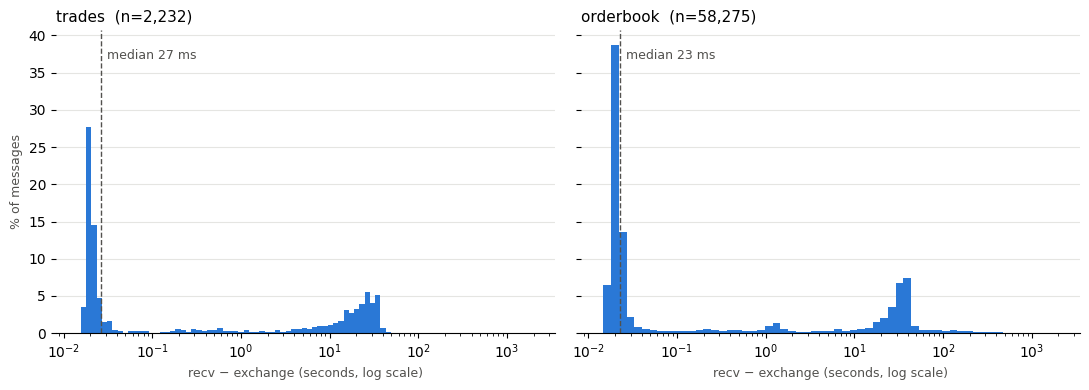

In [12]:
# The latency isn't horrible even the tail end of the distribution, but 10-30 seconds is concerning
# To do: in which markets does this happen in?
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, sharex=True)

plot_latency_distribution(df_trades, "trades", ax=axes[0])
plot_latency_distribution(df_books, "orderbook", ax=axes[1])

axes[1].set_ylabel("")
fig.tight_layout()

EDA: msg_type

In [13]:
# Seems to be only one message type in msg_type column of df_trades
df_trades["msg_type"].unique()

<StringArray>
['trade']
Length: 1, dtype: string

In [14]:
df_books["msg_type"].unique()

<StringArray>
['update', 'snapshot']
Length: 2, dtype: string

In [29]:
## To do - Need to figure out more about this

EDA: river_id

Not clear to me what river_id means, but they seem to be some type of identifiers, and they are mostly similar between these 2 tables df_books and df_trades.  df_books has 33 river_id and df_trades has 31, those 31 are shared, so df_books has 2 extra river_id

In [23]:
df_books["river_id"].unique()

array([11510160, 11510159, 11510161, 11510175, 11510174, 11510173,
       11140503, 11510195, 11510194, 11510193, 11510188, 11510186,
       11510158, 11510157, 11510153, 11510154, 11510155, 11510156,
       11510162, 11510163, 11510171, 11510172, 11510176, 11510177,
       11510185, 11510187, 11510189, 11510190, 11510191, 11510192,
       11510196, 11510197, 11510198])

In [24]:
df_trades["river_id"].unique()

array([11140503, 11510158, 11510159, 11510160, 11510174, 11510173,
       11510157, 11510156, 11510161, 11510163, 11510187, 11510162,
       11510185, 11510177, 11510194, 11510188, 11510171, 11510153,
       11510155, 11510175, 11510154, 11510189, 11510186, 11510193,
       11510172, 11510192, 11510190, 11510176, 11510195, 11510191,
       11510198])

In [25]:
df_books["river_id"].nunique()

33

In [26]:
df_trades["river_id"].nunique()

31

In [27]:
set(df_books["river_id"]) - set(df_trades["river_id"])

{11510196, 11510197}

EDA on column native_id

Similarly, in df_trades, there are 31 native_id, and in df_books, there are 33 native_id.  There are 2 extra in df_books.  Question: are native_id and river_id a one-to-one mapping?  If I know one, I know the other field?

In [30]:
df_trades["native_id"].unique()

<StringArray>
[           'KXMLBRFI-26AUG051940PITMIL',
        'KXMLBTOTAL-26AUG051940PITMIL-7',
        'KXMLBTOTAL-26AUG051940PITMIL-8',
        'KXMLBTOTAL-26AUG051940PITMIL-9',
      'KXMLBF5TOTAL-26AUG051940PITMIL-4',
      'KXMLBF5TOTAL-26AUG051940PITMIL-3',
        'KXMLBTOTAL-26AUG051940PITMIL-6',
        'KXMLBTOTAL-26AUG051940PITMIL-5',
       'KXMLBTOTAL-26AUG051940PITMIL-10',
       'KXMLBTOTAL-26AUG051940PITMIL-12',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-MIL4',
       'KXMLBTOTAL-26AUG051940PITMIL-11',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-MIL2',
      'KXMLBF5TOTAL-26AUG051940PITMIL-7',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-PIT4',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-MIL5',
      'KXMLBF5TOTAL-26AUG051940PITMIL-1',
        'KXMLBTOTAL-26AUG051940PITMIL-2',
        'KXMLBTOTAL-26AUG051940PITMIL-4',
      'KXMLBF5TOTAL-26AUG051940PITMIL-5',
        'KXMLBTOTAL-26AUG051940PITMIL-3',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-MIL6',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-MIL3',
 'KXMLBTEAMTOTAL-26A

In [31]:
df_books["native_id"].unique()

<StringArray>
[       'KXMLBTOTAL-26AUG051940PITMIL-9',
        'KXMLBTOTAL-26AUG051940PITMIL-8',
       'KXMLBTOTAL-26AUG051940PITMIL-10',
      'KXMLBF5TOTAL-26AUG051940PITMIL-5',
      'KXMLBF5TOTAL-26AUG051940PITMIL-4',
      'KXMLBF5TOTAL-26AUG051940PITMIL-3',
            'KXMLBRFI-26AUG051940PITMIL',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-PIT5',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-PIT4',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-PIT3',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-MIL5',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-MIL3',
        'KXMLBTOTAL-26AUG051940PITMIL-7',
        'KXMLBTOTAL-26AUG051940PITMIL-6',
        'KXMLBTOTAL-26AUG051940PITMIL-2',
        'KXMLBTOTAL-26AUG051940PITMIL-3',
        'KXMLBTOTAL-26AUG051940PITMIL-4',
        'KXMLBTOTAL-26AUG051940PITMIL-5',
       'KXMLBTOTAL-26AUG051940PITMIL-11',
       'KXMLBTOTAL-26AUG051940PITMIL-12',
      'KXMLBF5TOTAL-26AUG051940PITMIL-1',
      'KXMLBF5TOTAL-26AUG051940PITMIL-2',
      'KXMLBF5TOTAL-26AUG051940PITMIL-6',
      'KXMLBF5TOTAL-

In [33]:
set(df_books["native_id"]) - set(df_trades["native_id"])

{'KXMLBTEAMTOTAL-26AUG051940PITMIL-PIT6',
 'KXMLBTEAMTOTAL-26AUG051940PITMIL-PIT7'}